# Temporal Difference (TD) learning - Q Learning algorithm

## Setup froken lake env

In [7]:
import random
import numpy as np
from IPython.display import display, clear_output
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [8]:
def generate_grid_randomly(n_rows, n_cols, n_holes=4):
    """
    Generate a random 2D Frozen Lake grid.

    The grid consists of:
    - 'F' : Frozen (safe) cells
    - 'H' : Holes (terminal failure states)
    - 'S' : Start state
    - 'G' : Goal state

    Args:
        n_rows (int): Number of rows in the grid.
        n_cols (int): Number of columns in the grid.
        n_holes (int, optional): Number of hole cells to place.
            Defaults to 4.

    Returns:
        list[list[str]]: A 2D list representing the Frozen Lake grid.
    """
    
    grid = [["F" for _ in range(n_cols)] for _ in range(n_rows)]    
    states = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    
    random.shuffle(states)

    for i in range(0, n_holes):
        hole = states[i%(n_rows*n_cols)]
        r, c = hole
        
        grid[r][c] = "H"

    # start state
    r, c = states[-1]
    grid[r][c] = "S"

    # goal state
    r, c = states[-2]
    grid[r][c] = "G"

    return grid

In [9]:
ACTION_NAME_TO_IDX = {
    "left": 0,
    "down": 1,
    "right": 2,
    "up": 3
}
ACTION_IDX_TO_NAME = {v:k for k,v in ACTION_NAME_TO_IDX.items()}
ACTION_TO_STEP_MAPPER = {
    0: (0, -1), # left means staying in the same row (row unchanged), moving one column left from the current cell i.e -1
    1: (1, 0), # down means moving to the next row (+1 row) but staying in the same column
    2: (0, 1), # right means staying in the same row (row unchanged), moving to the subsequent right column i.e +1
    3: (-1, 0) # up means staying in the same column but moving one row up i.e -1 
}

In [10]:
class FrozenLakeEnvironment:
    def __init__(self, grid, slippery=True):
        self.grid = grid
        self.n_rows = len(grid)
        self.n_cols = len(grid[0])
        self.slippery = slippery
        self.allowed_actions = list(ACTION_NAME_TO_IDX.values())
        
        self.action_names_to_idx = ACTION_NAME_TO_IDX
        self.action_to_step_mapper = ACTION_TO_STEP_MAPPER
        
        self.start_state = self.__find("S")
        self.goal_state = self.__find("G")
        self.current_state = self.start_state
        self._display_handle = None

    def __find(self, value):
        """
        Find the position of a given value in the grid.

        Iterates through the grid and returns the first (row, column)
        coordinate where the specified value is found.
    
        Args:
            value (str): The grid cell value to search for
                (e.g., 'S', 'G', 'H', 'F').
    
        Returns:
            tuple[int, int] | None: The (row, column) position of the value
            if found; otherwise, None.
        
        """
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if self.grid[r][c] == value:
                    return (r, c)

    def __is_terminal(self, state):
        """
        check if the given state is terminating state or not (G or H)
        """
        r, c = state
        return self.grid[r][c] in ["G", "H"]

    def __move(self, state, action):
        """
        Compute the next state given a current state and an action.
    
        The agent is moved according to the action mapping. If the action
        would cause the agent to step outside the grid boundaries, the
        position is clipped to remain within valid limits.
    
        Args:
            state (tuple[int, int]): Current (row, column) position
                of the agent.
            action (int): Action index mapped to a movement direction
                via `self.action_to_step_mapper`.
    
        Returns:
            tuple[int, int]: The next (row, column) state after applying
            the action.
        """
        r, c = state
        step_r, step_c = self.action_to_step_mapper[action]
        new_r = min(max(0, r+step_r), self.n_rows -1) #make sure step is a valid one
        new_c = min(max(0, c+step_c), self.n_cols -1)
        return new_r, new_c

    def step(self, current_state, action):
        """
        The core Model-Free interface. 
        Agent provides an action, environment returns (next_state, reward, done).
        """
        if self.__is_terminal(current_state):
            return {"new_state": current_state,
                    "reward": 0,
                    "game_over": True}
                    
        actual_action = action
        if self.slippery:
            # 70% chance of success, 10% chance for each other direction
            roll = random.random()
            if roll < 0.7: # 70%
                actual_action = action
            elif roll < 0.8: # 10%
                actual_action = (action + 1) % len(self.allowed_actions)
            elif roll < 0.9: # 10%
                actual_action = (action + 2) % len(self.allowed_actions)
            else: # 10%
                actual_action = (action + 3) % len(self.allowed_actions)
        else:
            actual_action = action
        
        new_state = self.__move(current_state, actual_action)
        r, c = new_state
        cell = self.grid[r][c]
            
        if cell == "G":
            reward = 10
        elif cell == "H":
            reward = 0
        else:
            reward = 0
                
        game_over = cell in ["H", "G"]
        return {"new_state": new_state,
                "reward": reward,
                "game_over": game_over}
    
    def n_states(self):
        return self.n_rows * self.n_cols
    
    def n_actions(self):
        return len(self.allowed_actions) 

    def render(self, policy, current_state, episode_num=0, step_num=0, total_reward=0, sleep_time=0.1):
        
        rows, cols = self.n_rows, self.n_cols
        icons = {"S": "🚀", "H": "🕳️", "G": "🏁", "F": "❄️"}
        arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    
        grid_display = []
        for r in range(rows):
            row_display = []
            for c in range(cols):
                tile = self.grid[r][c]
                if (r, c) == current_state:
                    content = "🤖" 
                elif tile in ["S", "F"]:
                    action = policy[r][c]
                    content = f"{icons[tile]} {arrows[action]}"
                else:
                    content = icons[tile]
                row_display.append(content)
            grid_display.append(row_display)
    
        df = pd.DataFrame(grid_display)
    
        def style_cells(val):
            style = 'width: 60px; height: 60px; text-align: center; font-size: 20px; border: 1px solid #dee2e6;'
            if "🤖" in val: return style + 'background-color: #fff3cd; border: 2px solid #ffc107;' 
            if "🏁" in val: return style + 'background-color: #d4edda;' 
            if "🕳️" in val: return style + 'background-color: #f8d7da;' 
            return style + 'background-color: #89cfef;'
    
        # Generate the styled HTML for the table
        styled_html = df.style.map(style_cells).to_html()
        
        # Combine Header and Table into one HTML string
        header_html = f"<div style='font-family: sans-serif; margin-bottom: 10px;'>" \
                      f"<b>Episode:</b> {episode_num} | <b>Step:</b> {step_num} | <b>Score:</b> {total_reward}</div>"
        
        full_output = HTML(header_html + styled_html)
    
        if self._display_handle is None:
            # First time: display the combined HTML and capture handle
            self._display_handle = display(full_output, display_id=True)
        else:
            # Subsequent steps: update the same handle with the new combined HTML
            self._display_handle.update(full_output)
        
        time.sleep(sleep_time)

## TD learning - Q-learning algorithm

- sarsa can estimate the action values of the given policy. It must combine with the policy improvement step to find the optimal policy.
- Q-learning directly estimates the optimal action values, so there is no need to alternate between policy evaluation and policy improvement.

- There exists two policies in TD learning task
  - the behavior policy is used to generate experience samples
  - the target policy is constantly updated toward an optimal policy
- On-policy vs off-policy
  - On-policy: when behavior policy is same as target policy; sarsa is an on-policy algorithm
  - Off-policy: when they are different; q-learning is an off-policy algorithm

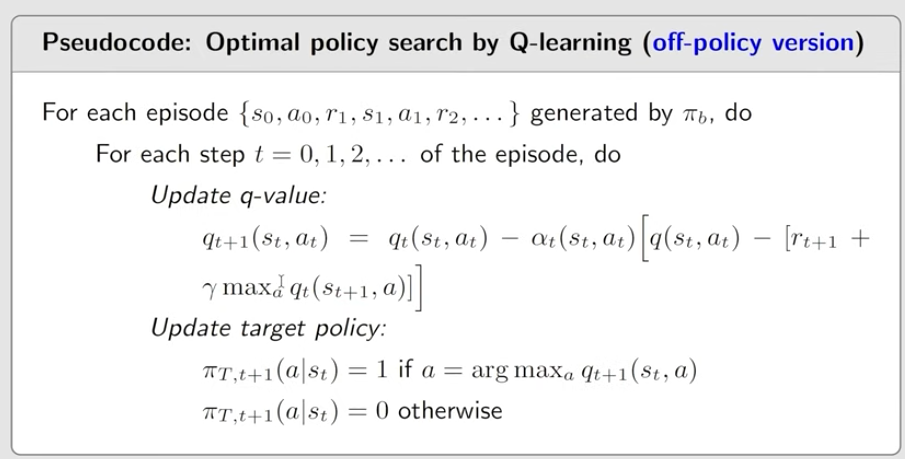

In [11]:
def state_2d_to_1d(state_coords, n_cols):
    """
    Converts (row, col) to a single integer index.
    
    Args:
        state_coords (tuple): (row, col)
        n_cols (int): Number of columns in the grid
    """
    r, c = state_coords
    return r * n_cols + c

def state_1d_to_2d(state_index, n_cols):
    """
    Converts a single integer index back to (row, col).
    
    Args:
        state_index (int): The 1D state representation
        n_cols (int): Number of columns in the grid
    """
    r = state_index // n_cols
    c = state_index % n_cols
    return (r, c)

In [12]:
def randomly_state_action_pair(state_list, action_list):
    # select element uniformly will ensure all the state, action will be selected eventually
    s = random.choice(state_list)    
    a = random.choice(action_list)
    return (s, a)

In [13]:
def epsilon_greedy_policy(Q, state, actions, epsilon=0.2):
    if random.random() < epsilon:
        return random.choice(actions) # explore
    else:
        return np.argmax(Q[state]) # exploit

def get_greedy_policy(env, Q, states):
    policy = np.zeros((env.n_rows, env.n_cols), dtype=np.int8)
    for s in states:
        r, c = state_1d_to_2d(s, env.n_cols)
        policy[r][c] = np.argmax(Q[s])
    return policy.tolist()  

In [14]:
def run_episode(env, Q, state_idx, action, episode_idx, alpha=0.1, gamma=0.1, verbose=0):
    step = 0
    while True:
        r_c_state = state_1d_to_2d(state_idx, env.n_cols)
        out = env.step(r_c_state, action)
        reward = out["reward"]

        next_r_c_state = out["new_state"]
        is_terminated = out["game_over"] # True if hole or goal ?

        next_state_idx = state_2d_to_1d(next_r_c_state, env.n_cols)
        
        # update Q value
        Q[state_idx][action] = Q[state_idx][action] - alpha*(Q[state_idx][action] - (reward + gamma*np.max(Q[next_state_idx]))) 
        
        state_idx = next_state_idx
        action = epsilon_greedy_policy(Q,
                                next_state_idx,
                                env.allowed_actions,
                                epsilon=1.0) # behaviour policy
        
        if verbose == 1:
            print(f"step {step}: state: {state} -> Action: {action} -> Reward: {reward} -> Next state: {next_state}")
        elif verbose == 2:
            policy = get_greedy_policy(env, Q, list(range(env.n_states())))
            env.render(policy, next_r_c_state, episode_idx, step, reward)
            
        if is_terminated:
            break
            
        step += 1
        
    return Q, get_greedy_policy(env, Q, list(range(env.n_states())))

In [25]:
def run_q_learning(env, n_episodes=500, verbose=0):
    policy_history = []
    Q_history = []

    n_states = env.n_states()
    n_actions = env.n_actions()

    states_list = list(range(n_states))
    actions_list = list(range(n_actions))
    
    Q = np.zeros((n_states, n_actions), dtype=np.float32)
    for episode_idx in range(n_episodes):
        s, a = randomly_state_action_pair(states_list,
                                          actions_list)
        
        Q, greedy_policy = run_episode(env,
                                       Q, s, a, 
                                       episode_idx,
                                       alpha=0.1,
                                       gamma=0.9,
                                       verbose=verbose)

        policy_history.append(greedy_policy)
        Q_history.append(Q)
    return Q, policy_history, Q_history

In [44]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    slippery=True)

In [45]:
frozen_lake.n_rows

4

In [46]:
Q, policy_history, Q_history = run_q_learning(frozen_lake, n_episodes=1000, verbose=0)

In [47]:
policy = policy_history[-1]
np.array(policy)

array([[2, 1, 2, 1],
       [2, 1, 0, 1],
       [2, 2, 2, 0],
       [3, 0, 2, 3]])

# Render policy

In [53]:
import matplotlib.pyplot as plt

In [54]:
ARROWS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

In [55]:
import pandas as pd
from IPython.display import display

def render_policy_and_value(env, policy, Q=None):
    """
    Render the policy and optionally the state-value function in a 
    visually appealing grid format using emojis and arrows.

    Args:
        env: Frozen Lake environment object with `grid`, `n_rows`, `n_cols`
        policy: 2D array of actions for each state
        V: 2D array of state values (optional)
    """
    rows, cols = env.n_rows, env.n_cols
    # Icons and arrows
    icons = {"S": "🚀", "H": "🕳️", "G": "🏁", "F": ""}
    arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    # --- Policy Display ---
    grid_policy = []
    for r in range(rows):
        row_display = []
        for c in range(cols):
            tile = env.grid[r][c]
            if tile in ["S", "F"]:
                action = policy[r][c]
                content = f"{icons[tile]} {arrows[action]}"
            else:
                content = icons[tile]
            row_display.append(content)
        grid_policy.append(row_display)

    df_policy = pd.DataFrame(grid_policy)
    
    # --- Value Function Display ---
    if Q is not None:
        grid_value = []
        q_r, q_c = Q.shape
        for r in range(q_r):
            row_display = []
            for c in range(q_c):
                val = Q[r][c]
                row_display.append(f"{val:.2f}")
            grid_value.append(row_display)
        df_value = pd.DataFrame(grid_value)

    # --- Styling function ---
    def style_cells(val):
        style = 'width: 60px; height: 60px; text-align: center; font-size: 20px; border: 1px solid #dee2e6;'
        if "🏁" in val: return style + 'background-color: #d4edda;' # Green
        if "🕳️" in val: return style + 'background-color: #f8d7da;' # Red
        if "🚀" in val: return style + 'background-color: #cce5ff;' # Blue
        return style + 'background-color: #89cfef;'  # Frozen tiles

    # --- Render ---
    print("Policy:")
    display(df_policy.style.map(style_cells))
    
    if Q is not None:
        print("action-Value Function:")
        display(df_value.style.set_properties(**{
            'width': '60px', 
            'height': '60px', 
            'text-align': 'center', 
            'font-size': '16px',
            'border': '1px solid #dee2e6'
        }))

In [56]:
policy, Q

([[2, 1, 2, 1], [2, 1, 0, 1], [2, 2, 2, 0], [3, 0, 2, 3]],
 array([[3.313992 , 3.7189019, 3.7667496, 3.5349216],
        [3.6768374, 4.3194933, 4.1795034, 3.7884502],
        [3.2765722, 0.8198712, 3.981242 , 3.8332458],
        [4.930076 , 6.1284847, 5.9620614, 5.649149 ],
        [3.9061723, 4.0789742, 4.4878106, 3.6060338],
        [3.292357 , 5.3573375, 1.2784482, 3.8834233],
        [0.       , 0.       , 0.       , 0.       ],
        [2.8186874, 7.769675 , 6.0722938, 6.2845864],
        [4.4141517, 3.5002465, 4.939573 , 4.0884466],
        [4.6193   , 2.407938 , 6.2122416, 4.381365 ],
        [5.234031 , 4.503369 , 7.970164 , 1.3791192],
        [0.       , 0.       , 0.       , 0.       ],
        [2.206591 , 3.0708315, 0.7701566, 3.4505334],
        [0.       , 0.       , 0.       , 0.       ],
        [2.382476 , 5.024106 , 6.0629606, 6.0463014],
        [6.61187  , 7.760651 , 7.5674467, 9.173414 ]], dtype=float32))

In [57]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,→,↓,🚀 →,↓
1,→,↓,🕳️,↓
2,→,→,→,🏁
3,↑,🕳️,→,↑


# Play with different grid setup

In [58]:
grid = generate_grid_randomly(4, 4, n_holes=5)
grid

[['H', 'H', 'F', 'F'],
 ['F', 'G', 'F', 'S'],
 ['F', 'H', 'H', 'H'],
 ['F', 'F', 'F', 'F']]

In [59]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    slippery=True)

In [60]:
Q, policy_history, Q_history = run_q_learning(frozen_lake, n_episodes=5000, verbose=0)

In [61]:
policy = policy_history[-1]

In [62]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,🕳️,🕳️,→,↓
1,→,🏁,←,🚀 ←
2,↑,🕳️,🕳️,🕳️
3,↑,←,←,←
